# **Estadística Inferencial**

## **Muestreo y muestras aleatorias**


## **Muestreo Probabilístico**

Vamos a usar este dataset para casi todos los ejemplos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Importar Dataset a usar
import pandas as pd
import numpy as np

data = pd.read_csv('/content/drive/MyDrive/Esp Analitica Avanzada/Estadistica Aplicada con Python/iris.csv')
data

data_prueba = data[['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo']]
data_prueba.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   longitud_sepalo  150 non-null    float64
 1   ancho_sepalo     150 non-null    float64
 2   longitud_petalo  150 non-null    float64
 3   ancho_petalo     150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


# Tecnicas para Determinar el Tamaño de la Muestra

### **Muestreo para una Media Poblacional (Población Infinita):**

* Aplica cuando la variable es **numérica** y se desea estimar la media.
* Se usa si no hay un tamaño de población limitado o si 𝑁 es muy grande >10.000.


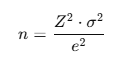

### **Muestreo para una Proporción Poblacional (Población Infinita):**

* Aplica cuando la variable es categórica y se desea estimar una proporción.
* Se usa cuando el tamaño total de la población no está definido.

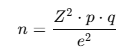

### **Muestreo con Corrección para Población Finita:**

* Se aplica cuando 𝑁 es conocido y pequeño <10.000.
* Si la muestra es grande en relación con 𝑁, se necesita la corrección para evitar un tamaño de muestra innecesariamente grande.

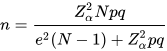

In [ ]:
# Poblacion = N
data.shape[0]

150

In [13]:
import numpy as np
import pandas as pd
import scipy.stats as stats

def calcular_tamano_muestra_df(df, columna, confianza=0.95, error=0.05, N=None):
    """
    Calcula el tamaño de la muestra a partir de un DataFrame, almacenando el resultado en la variable `n`.

    Parámetros:
    - df: DataFrame de pandas que contiene los datos.
    - columna: Nombre de la columna sobre la cual calcular la muestra.
    - confianza: Nivel de confianza (por defecto 95%).
    - error: Margen de error permitido.
    - N: Tamaño total de la población (opcional, si se quiere aplicar corrección para población finita).

    Retorna:
    - n: Tamaño de la muestra recomendado (entero).
    """
    global n

    # Verificar que la columna exista
    if columna not in df.columns:
        raise ValueError(f"Error: La columna '{columna}' no existe en el DataFrame.")

    # Eliminar valores nulos para evitar errores
    datos = df[columna].dropna()

    # Si la columna está vacía después de eliminar nulos, devolver error
    if datos.empty:
        raise ValueError(f"Error: La columna '{columna}' solo contiene valores nulos.")

    # Determinar si la variable es numérica o categórica
    if pd.api.types.is_numeric_dtype(datos):
        tipo_variable = "numérica"
        sigma = np.std(datos, ddof=1)  # Desviación estándar muestral
        Z = stats.norm.ppf(1 - (1 - confianza) / 2)
        n = (Z**2 * sigma**2) / error**2

    elif pd.api.types.is_object_dtype(datos) or pd.api.types.is_categorical_dtype(datos):
        tipo_variable = "categórica"
        p = datos.value_counts(normalize=True).iloc[0]  # Proporción de la categoría más frecuente
        q = 1 - p
        Z = stats.norm.ppf(1 - (1 - confianza) / 2)
        n = (Z**2 * p * q) / error**2

    else:
        raise ValueError(f"Error: No se pudo determinar si la columna '{columna}' es numérica o categórica.")

    # Aplicar corrección para población finita si N está definido
    if N is not None:
        n = (N * n) / ((N - 1) + n)

    # Convertir a entero redondeado hacia arriba
    n = int(np.ceil(n))

    return n  # Devuelve el tamaño de la muestra como un número entero


In [19]:
calcular_tamano_muestra_df(data_prueba,'longitud_sepalo',error=0.05, N=150)

132

###**Muestreo aleatorio simple (MAS)**

La función **muestreo_aleatorio_simple** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear.\
**tamaño_muestra:** el tamaño de la muestra deseada.

In [20]:
# Función para realizar un muestreo aleatorio simple
# Tomando una muestra utilizando el muestreo aleatorio simple


import pandas as pd

# Función para realizar un muestreo aleatorio simple
def muestreo_aleatorio_simple(data, tamaño_muestra, random_state=None):
    """
    Realiza un muestreo aleatorio simple (MAS) a partir de un DataFrame.

    Parámetros:
    - data: DataFrame que contiene la población.
    - tamaño_muestra: Número de elementos a seleccionar.
    - random_state: Semilla para reproducibilidad (opcional).

    Retorna:
    - Un DataFrame con la muestra seleccionada.
    """
    if tamaño_muestra > len(data):
        raise ValueError("El tamaño de la muestra no puede ser mayor que la población.")

    # Realizar el muestreo aleatorio simple
    muestra = data.sample(n=tamaño_muestra, random_state=random_state)

    return muestra

# Aplicación de la función con `n` ya calculado
datos_muestreo = muestreo_aleatorio_simple(data, n, random_state=42)

# Mostrar la muestra seleccionada
print(datos_muestreo)

     longitud_sepalo  ancho_sepalo  longitud_petalo  ancho_petalo  objetivo
73               6.1           2.8              4.7           1.2       1.0
18               5.7           3.8              1.7           0.3       0.0
118              7.7           2.6              6.9           2.3       2.0
78               6.0           2.9              4.5           1.5       1.0
76               6.8           2.8              4.8           1.4       1.0
..               ...           ...              ...           ...       ...
124              6.7           3.3              5.7           2.1       2.0
21               5.1           3.7              1.5           0.4       0.0
57               4.9           2.4              3.3           1.0       1.0
144              6.7           3.3              5.7           2.5       2.0
129              7.2           3.0              5.8           1.6       2.0

[132 rows x 5 columns]


### **Muestreo estratificado**

La función **estratificar_muestra** toma como entrada los siguientes argumentos: \
**data:** el conjunto de datos completo que se va a muestrear.\
**objetivo:** el nombre de la columna que contiene la variable objetivo. \
**test_size:** el tamaño de la muestra de prueba como una fracción del tamaño total de la muestra.\
**random_state:** el estado aleatorio para la reproducibilidad de los resultados

In [21]:
# Función para realizar un muestreo estratificado
# La estratificación se realiza en función de la variable 'objetivo'
# Tomando una muestra utilizando el muestreo estratificado

import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

def estratificar_muestra(data, columna_estrato, n, random_state=None):
    """
    Realiza un muestreo estratificado usando el tamaño de muestra.

    Parámetros:
    - data: DataFrame de pandas.
    - columna_estrato: Nombre de la columna que define los estratos (debe ser categórica).
    - n: Tamaño de la muestra previamente calculado.
    - random_state: Semilla aleatoria opcional para garantizar reproducibilidad.

    Retorna:
    - Un DataFrame con la muestra estratificada.
    """

    # Verificar que la columna existe en el DataFrame
    if columna_estrato not in data.columns:
        raise ValueError(f"Error: La columna '{columna_estrato}' no existe en el DataFrame.")

    # Verificar que `n` no sea mayor que la población
    if n > len(data):
        raise ValueError(f"Error: El tamaño de la muestra ({n}) no puede ser mayor que la población ({len(data)}).")

    # Convertir la columna a tipo categórico si no lo es
    if not pd.api.types.is_categorical_dtype(data[columna_estrato]):
        data[columna_estrato] = data[columna_estrato].astype("category")

    # Verificar si hay suficientes categorías en la columna para hacer estratificación
    if len(data[columna_estrato].unique()) < 2:
        raise ValueError(f"Error: La columna '{columna_estrato}' no tiene suficientes categorías para la estratificación.")

    # Aplicar StratifiedShuffleSplit con `n` como tamaño de muestra
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=n, random_state=random_state)

    # Extraer la muestra estratificada
    for _, test_index in strat_split.split(data, data[columna_estrato]):
        muestra_estratificada = data.loc[test_index]

    return muestra_estratificada


# Aplicamos el muestreo estratificado usando "Grupo" como columna de estratificación
muestra_estratificada = estratificar_muestra(data, "objetivo", n, random_state=42)

print("Muestra Estratificada:")
print(muestra_estratificada.head())


📌 Muestra Estratificada:
    longitud_sepalo  ancho_sepalo  longitud_petalo  ancho_petalo objetivo
6               4.6           3.4              1.4           0.3      0.0
44              5.1           3.8              1.9           0.4      0.0
47              4.6           3.2              1.4           0.2      0.0
15              5.7           4.4              1.5           0.4      0.0
53              5.5           2.3              4.0           1.3      1.0


<ipython-input-21-ff1ab2b90b08>:31: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(data[columna_estrato]):


### **Muestreo sistemático**

La función **muestreo_sistematico** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear. \
**tamaño_muestra:** el tamaño de la muestra deseada.

In [22]:
# Función para realizar un muestreo sistemático
# Tomando una muestra utilizando el muestreo sistemático

def muestreo_sistematico(data, tamaño_muestra, random_state=None):
    """
    Realiza un muestreo sistemático sobre un DataFrame.

    Parámetros:
    - data: DataFrame de pandas que contiene la población.
    - tamaño_muestra: Número de elementos a seleccionar.
    - random_state: Semilla opcional para garantizar reproducibilidad.

    Retorna:
    - Un DataFrame con la muestra sistemática.
    """

    # Verificar que el tamaño de la muestra no sea mayor que la población
    if tamaño_muestra > len(data):
        raise ValueError(f"Error: El tamaño de la muestra ({tamaño_muestra}) no puede ser mayor que la población ({len(data)}).")

    # Si la muestra es igual a la población, devolvemos todos los datos
    if tamaño_muestra == len(data):
        return data

    # Definir la distancia entre elementos seleccionados (k)
    k = len(data) // tamaño_muestra

    # Fijar la semilla para reproducibilidad (si se proporciona)
    if random_state is not None:
        np.random.seed(random_state)

    # Seleccionar el primer elemento aleatoriamente dentro del primer intervalo [0, k)
    primer_elemento = np.random.randint(0, k)

    # Crear los índices de los elementos seleccionados
    indices = range(primer_elemento, len(data), k)

    # Obtener la muestra sistemática
    muestra_sistematica = data.iloc[list(indices)]

    return muestra_sistematica


# Aplicamos el muestreo sistemático
muestra_sistematica = muestreo_sistematico(data, n, random_state=42)

print("Muestra Sistemática:")
print(muestra_sistematica.head())


📌 Muestra Sistemática:
   longitud_sepalo  ancho_sepalo  longitud_petalo  ancho_petalo objetivo
0              5.1           3.5              1.4           0.2      0.0
1              4.9           3.0              1.4           0.2      0.0
2              4.7           3.2              1.3           0.2      0.0
3              4.6           3.1              1.5           0.2      0.0
4              5.0           3.6              1.4           0.2      0.0


### **Muestreo por conglomerados**

En este ejemplo, creamos un conjunto de datos sintéticos que simula las opiniones de los ciudadanos de 50 barrios diferentes en una ciudad. \
Luego, seleccionamos 10 barrios al azar como conglomerados y tomamos todos los datos disponibles de esos barrios (muestra_conglomerados).

In [24]:
import pandas as pd
import numpy as np

data_conglomerado = pd.read_csv('/content/drive/MyDrive/Esp Analitica Avanzada/Estadistica Aplicada con Python/dataset_barrios.csv')
data_conglomerado

,Barrio,Opinion
0,Barrio 1,Positiva
1,Barrio 1,Neutral
2,Barrio 1,Neutral
3,Barrio 1,Neutral
4,Barrio 1,Positiva
...,...,...
15073,Barrio 50,Neutral
15074,Barrio 50,Negativa
15075,Barrio 50,Negativa
15076,Barrio 50,Negativa


La función **muestreo_conglomerados** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear. \
**variable_conglomerado:** el nombre de la variable que define los conglomerados.\
**num_conglomerados_seleccionados:** el número al azar de conglomerados que se van a seleccionar para la muestra.

In [26]:
# Función para realizar un muestreo por conglomerados
# Tomando una muestra utilizando el muestreo por conglomerados

import numpy as np
import pandas as pd

def muestreo_conglomerados(data, variable_conglomerado, num_conglomerados_seleccionados=None, random_state=None):
    """
    Realiza un muestreo por conglomerados seleccionando un número específico de conglomerados
    y tomando todos los elementos de los conglomerados seleccionados.

    Parámetros:
    - data: DataFrame de pandas.
    - variable_conglomerado: Nombre de la columna que define los conglomerados.
    - num_conglomerados_seleccionados: Número de conglomerados a seleccionar (opcional).
      Si no se proporciona, selecciona automáticamente un 30% de los conglomerados.
    - random_state: Semilla aleatoria opcional para garantizar reproducibilidad.

    Retorna:
    - Un DataFrame con la muestra por conglomerados.
    """

    # Verificar que la columna del conglomerado existe en el DataFrame
    if variable_conglomerado not in data.columns:
        raise ValueError(f"Error: La columna '{variable_conglomerado}' no existe en el DataFrame.")

    # Obtener los conglomerados únicos
    conglomerados = data[variable_conglomerado].unique()

    # Definir el número de conglomerados a seleccionar si no se especifica
    if num_conglomerados_seleccionados is None:
        num_conglomerados_seleccionados = max(1, int(0.3 * len(conglomerados)))  # 30% de los conglomerados

    # Verificar que no se pidan más conglomerados de los que existen
    if num_conglomerados_seleccionados > len(conglomerados):
        raise ValueError(f"Error: Se solicitaron {num_conglomerados_seleccionados} conglomerados, pero solo hay {len(conglomerados)} disponibles.")

    # Fijar la semilla para reproducibilidad (si se proporciona)
    if random_state is not None:
        np.random.seed(random_state)

    # Seleccionar aleatoriamente los conglomerados sin repetición
    conglomerados_seleccionados = np.random.choice(conglomerados, num_conglomerados_seleccionados, replace=False)

    # Filtrar el DataFrame para incluir solo los datos de los conglomerados seleccionados
    muestra_conglomerados = data[data[variable_conglomerado].isin(conglomerados_seleccionados)]

    return muestra_conglomerados

muestra_conglomerados = muestreo_conglomerados(data_conglomerado, "Barrio", num_conglomerados_seleccionados=10, random_state=42)

print("Muestra por Conglomerados:")
print(muestra_conglomerados.head())

# Ver cuántos conglomerados fueron seleccionados
print("\n Conglomerados seleccionados en la muestra:")
print(muestra_conglomerados["Barrio"].unique())

📌 Muestra por Conglomerados:
         Barrio   Opinion
3631  Barrio 14  Negativa
3632  Barrio 14  Positiva
3633  Barrio 14  Negativa
3634  Barrio 14   Neutral
3635  Barrio 14  Negativa

📊 Conglomerados seleccionados en la muestra:
['Barrio 14' 'Barrio 18' 'Barrio 20' 'Barrio 26' 'Barrio 27' 'Barrio 31'
 'Barrio 33' 'Barrio 40' 'Barrio 46' 'Barrio 49']


Se desea obtener una muestra de tamaño fijo de cada barrio seleccionado, en lugar de tomar todos los datos disponibles.

La función **muestreo_conglomerados_tamaño_fijo** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear.\
**variable_conglomerado:** el nombre de la variable que define los conglomerados.\
**num_conglomerados_seleccionados:** el número de conglomerados que se van a seleccionar para la muestra.\
**tamaño_muestra_por_conglomerado:** el tamaño de muestra por conglomerado deseado.

In [27]:
# Se desea obtener una muestra de tamaño fijo de cada barrio seleccionado

import numpy as np
import pandas as pd

def muestreo_conglomerados_tamaño_fijo(data, variable_conglomerado, num_conglomerados_seleccionados, tamaño_muestra_por_conglomerado, random_state=None):
    """
    Realiza un muestreo por conglomerados donde se seleccionan `num_conglomerados_seleccionados` conglomerados
    y luego se toma un `tamaño_muestra_por_conglomerado` de cada uno.

    Parámetros:
    - data: DataFrame de pandas.
    - variable_conglomerado: Nombre de la columna que define los conglomerados.
    - num_conglomerados_seleccionados: Número de conglomerados a seleccionar aleatoriamente.
    - tamaño_muestra_por_conglomerado: Cantidad de muestras a extraer de cada conglomerado seleccionado.
    - random_state: Semilla opcional para reproducibilidad.

    Retorna:
    - Un DataFrame con la muestra seleccionada.
    """

    # Verificar que la columna de conglomerados existe en el DataFrame
    if variable_conglomerado not in data.columns:
        raise ValueError(f"Error: La columna '{variable_conglomerado}' no existe en el DataFrame.")

    # Obtener los conglomerados únicos
    conglomerados = data[variable_conglomerado].unique()

    # Verificar que el número de conglomerados seleccionados no sea mayor al total disponible
    if num_conglomerados_seleccionados > len(conglomerados):
        raise ValueError(f"Error: Se pidieron {num_conglomerados_seleccionados} conglomerados, pero solo hay {len(conglomerados)} disponibles.")

    # Fijar la semilla para reproducibilidad (si se proporciona)
    if random_state is not None:
        np.random.seed(random_state)

    # Seleccionar aleatoriamente los conglomerados sin repetición
    conglomerados_seleccionados = np.random.choice(conglomerados, num_conglomerados_seleccionados, replace=False)

    # Filtrar solo los conglomerados seleccionados
    data_seleccionada = data[data[variable_conglomerado].isin(conglomerados_seleccionados)]

    # Verificar que cada conglomerado tiene suficientes datos antes de hacer el muestreo
    insuficientes = data_seleccionada.groupby(variable_conglomerado).filter(lambda x: len(x) < tamaño_muestra_por_conglomerado)

    if not insuficientes.empty:
        raise ValueError(f"Error: Algunos conglomerados tienen menos de {tamaño_muestra_por_conglomerado} observaciones.")

    # Aplicar el muestreo fijo a cada conglomerado seleccionado
    muestra_fija_conglomerados = data_seleccionada.groupby(variable_conglomerado).sample(n=tamaño_muestra_por_conglomerado, random_state=random_state)

    return muestra_fija_conglomerados

muestra_conglomerados_fijo = muestreo_conglomerados_tamaño_fijo(data_conglomerado, "Barrio", 10, 10, random_state=42)

print("Muestra por Conglomerados con Tamaño Fijo:")
print(muestra_conglomerados_fijo.head())

# Ver cuántos conglomerados fueron seleccionados
print("\n Conglomerados seleccionados en la muestra:")
print(muestra_conglomerados_fijo["Barrio"].unique())


📌 Muestra por Conglomerados con Tamaño Fijo:
         Barrio   Opinion
3713  Barrio 14   Neutral
3646  Barrio 14  Negativa
3742  Barrio 14  Negativa
3808  Barrio 14  Negativa
3707  Barrio 14  Positiva

📊 Conglomerados seleccionados en la muestra:
['Barrio 14' 'Barrio 18' 'Barrio 20' 'Barrio 26' 'Barrio 27' 'Barrio 31'
 'Barrio 33' 'Barrio 40' 'Barrio 46' 'Barrio 49']


### **Muestreo aleatorio mixto o por etapas múltiples**

Primera etapa: Realizamos un muestreo estratificado por especie de iris, seleccionando 15 flores de cada especie.

Segunda etapa: Dentro de cada estrato (especie) de la muestra estratificada, realizamos un muestreo aleatorio simple, seleccionando 5 flores de cada especie.

La función **muestreo_estratificado_multiple** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear.\
**variable_estratificacion:** el nombre de la variable que define los estratos.\
**tamaño_muestra_final:** el tamaño de muestra deseado para cada estrato después de la estratificación múltiple.\
**num_muestras_estrato:** el número de muestras a tomar de cada estrato en la etapa 1 de la estratificación.

In [28]:
# Función para realizar un muestreo por racimos
# Tomando una muestra utilizando el muestreo por racimos

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Cargar dataset de Iris
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["species"] = [iris.target_names[i] for i in iris.target]  # Convertir números a nombres de especies

# Función de Muestreo Estratificado Múltiple (Automatizado)
def muestreo_estratificado_multiple(data, variable_estratificacion, num_muestras_estrato, tamaño_muestra_final, random_state=None):
    """
    Realiza un muestreo por múltiples etapas en cualquier dataset.

    Parámetros:
    - data: DataFrame de pandas.
    - variable_estratificacion: Columna sobre la cual se quiere hacer la estratificación.
    - num_muestras_estrato: Número de observaciones a extraer en la primera etapa de cada estrato.
    - tamaño_muestra_final: Número de observaciones a extraer en la segunda etapa dentro de cada estrato.
    - random_state: Semilla aleatoria opcional para reproducibilidad.

    Retorna:
    - Un DataFrame con la muestra final.
    """

    # Verificar que la columna de estratificación existe
    if variable_estratificacion not in data.columns:
        raise ValueError(f"Error: La columna '{variable_estratificacion}' no existe en el DataFrame.")

    # Verificar que los estratos tienen suficientes datos
    insuficientes = data.groupby(variable_estratificacion).filter(lambda x: len(x) < num_muestras_estrato)
    if not insuficientes.empty:
        raise ValueError(f"Error: Algunos estratos tienen menos de {num_muestras_estrato} observaciones.")

    # Etapa 1: Muestreo Estratificado
    muestra_estratificada = data.groupby(variable_estratificacion).sample(n=num_muestras_estrato, random_state=random_state)

    # Verificar que la muestra estratificada tenga suficientes datos para la segunda etapa
    if tamaño_muestra_final > num_muestras_estrato:
        raise ValueError(f"Error: El tamaño de la muestra final ({tamaño_muestra_final}) no puede ser mayor que la cantidad seleccionada en la primera etapa ({num_muestras_estrato}).")

    # Etapa 2: Muestreo Aleatorio Simple dentro de cada estrato
    muestra_etapas_multiples = muestra_estratificada.groupby(variable_estratificacion).sample(n=tamaño_muestra_final, random_state=random_state)

    return muestra_etapas_multiples


muestra_mixta_iris = muestreo_estratificado_multiple(df_iris, "species", num_muestras_estrato=20, tamaño_muestra_final=10, random_state=42)

print("Muestra por Múltiples Etapas en Iris:")
print(muestra_mixta_iris.head())

# Verificar proporciones
print("\n Proporciones de especies en la muestra:")
print(muestra_mixta_iris["species"].value_counts(normalize=True))


Muestra por Múltiples Etapas en Iris:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
13                4.3               3.0                1.1               0.1   
46                5.1               3.8                1.6               0.2   
6                 4.6               3.4                1.4               0.3   
39                5.1               3.4                1.5               0.2   
32                5.2               4.1                1.5               0.1   

   species  
13  setosa  
46  setosa  
6   setosa  
39  setosa  
32  setosa  

 Proporciones de especies en la muestra:
species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64


La muestra final (muestra_etapas_multiples) contiene 5 flores de cada especie, seleccionadas a través de un proceso de muestreo por etapas múltiples

##**Muestreo no probabilístico**

### **Muestreo por conveniencia**

En este ejemplo, simplemente seleccionamos las primeras 30 filas del conjunto de datos como muestra. Esto podría representar una situación en la que solo se tiene acceso a una parte limitada del conjunto de datos completo.

La función **muestreo_conveniencia** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear. \
**tamaño_muestra:** el tamaño de muestra deseado.

In [ ]:
def muestreo_conveniencia(data, tamaño_muestra):
    muestra_conveniencia = data.head(tamaño_muestra)
    return muestra_conveniencia
muestreo_conveniencia(data, 30)

,longitud_sepalo,ancho_sepalo,longitud_petalo,ancho_petalo,objetivo
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
5,5.4,3.9,1.7,0.4,0.0
6,4.6,3.4,1.4,0.3,0.0
7,5.0,3.4,1.5,0.2,0.0
8,4.4,2.9,1.4,0.2,0.0
9,4.9,3.1,1.5,0.1,0.0


### **Muestreo por juicio**

En este ejemplo, seleccionamos 10 filas de cada especie de iris. Esto podría representar una situación en la que un experto en flores de iris selecciona muestras específicas en función de su conocimiento del tema.

La función **muestreo_juicio** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear. \
**variable_estratificacion:** el nombre de la variable que define los estratos.\
**tamaño_muestra_por_estrato:** el tamaño de muestra deseado por estrato.

In [ ]:
def muestreo_juicio(data, variable_estratificacion, tamaño_muestra_por_estrato):
    muestra_juicio = pd.DataFrame()
    for estrato in data[variable_estratificacion].unique():
        muestras_estrato = data[data[variable_estratificacion] == estrato].sample(tamaño_muestra_por_estrato)
        muestra_juicio = pd.concat([muestra_juicio, muestras_estrato], ignore_index=True)
    return muestra_juicio

muestreo_juicio(data, 'objetivo', 10)

,longitud_sepalo,ancho_sepalo,longitud_petalo,ancho_petalo,objetivo
0,5.1,3.8,1.6,0.2,0.0
1,4.8,3.0,1.4,0.1,0.0
2,5.1,3.3,1.7,0.5,0.0
3,5.5,3.5,1.3,0.2,0.0
4,4.8,3.4,1.9,0.2,0.0
5,5.1,3.7,1.5,0.4,0.0
6,5.0,3.0,1.6,0.2,0.0
7,4.3,3.0,1.1,0.1,0.0
8,4.8,3.0,1.4,0.3,0.0
9,4.7,3.2,1.3,0.2,0.0


### **Muestreo por cuotas**

En este ejemplo, seleccionamos 10 filas de cada especie de iris, pero sin garantizar que la selección sea aleatoria. Esto podría representar una situación en la que se seleccionan muestras basadas en ciertas características conocidas de la población (en este caso, la especie), pero sin garantizar la aleatoriedad en la selección.

La función **muestreo_cuotas** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear. \
**variable_estratificacion:** el nombre de la variable que define los estratos. \
**tamaño_muestra_por_estrato:** el tamaño de muestra deseado por estrato.

In [ ]:
def muestreo_cuotas(data, variable_estratificacion, tamaño_muestra_por_estrato):

    # Generar la muestra por cuotas
    muestra_cuotas = pd.DataFrame()
    for estrato in data[variable_estratificacion].unique():
        muestras_estrato = data[data[variable_estratificacion] == estrato].head(tamaño_muestra_por_estrato)
        muestra_cuotas = pd.concat([muestra_cuotas, muestras_estrato], ignore_index=True)
    return muestra_cuotas

muestreo_cuotas(data,'objetivo', 10)

,longitud_sepalo,ancho_sepalo,longitud_petalo,ancho_petalo,objetivo
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
5,5.4,3.9,1.7,0.4,0.0
6,4.6,3.4,1.4,0.3,0.0
7,5.0,3.4,1.5,0.2,0.0
8,4.4,2.9,1.4,0.2,0.0
9,4.9,3.1,1.5,0.1,0.0


### **Muestreo de bola de nieve**

Supongamos que queremos estudiar las características de las flores de iris pero tenemos un acceso limitado a ellas. En este caso, el muestreo de bola de nieve puede ser útil si cada flor seleccionada nos puede llevar a otras flores similares.

Nota: El algoritmo de k vecinos más cercanos, también conocido como KNN o k-NN, es un clasificador de aprendizaje supervisado no paramétrico, que utiliza la proximidad para hacer clasificaciones o predicciones sobre la agrupación de un punto de datos individual

La función **muestreo_bola_de_nieve** toma como entrada los siguientes argumentos:

**data:** el conjunto de datos completo que se va a muestrear.\
**variable_estratificacion:** el nombre de la variable que define los estratos. \
**tamaño_muestra_inicial:** el tamaño de muestra inicial para la bola de nieve. \
**k:** el número de vecinos a considerar en el algoritmo k-NN.

In [ ]:
# Función para realizar un muestreo bola de nieve
# Tomando una muestra utilizando el muestreo bola de nieve
import pandas as pd
from sklearn.neighbors import NearestNeighbors

def muestreo_bola_de_nieve(data, variable_estratificacion, tamaño_muestra_inicial, k):
    # Seleccionamos una muestra aleatoria de tamaño_muestra_inicial
    muestra_inicial = data.sample(tamaño_muestra_inicial)

    # Utilizamos el algoritmo k-NN para encontrar filas similares a la muestra inicial
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(data.drop(variable_estratificacion, axis=1).values)

    muestra_bola_de_nieve = muestra_inicial.copy()
    for index, row in muestra_inicial.iterrows():
        # Encontramos los k vecinos más cercanos (excluyendo la misma fila)
        distances, indices = nbrs.kneighbors([row.drop(variable_estratificacion).values])

        # Obtenemos las filas correspondientes a los vecinos más cercanos
        vecinos = data.iloc[indices[0][1:]]
        muestra_bola_de_nieve = pd.concat([muestra_bola_de_nieve, vecinos], ignore_index=True)

    return muestra_bola_de_nieve
muestreo_bola_de_nieve(data,'objetivo', 3, 3)

,longitud_sepalo,ancho_sepalo,longitud_petalo,ancho_petalo,objetivo
0,6.3,2.3,4.4,1.3,1.0
1,5.5,2.5,4.0,1.3,1.0
2,6.7,2.5,5.8,1.8,2.0
3,6.2,2.2,4.5,1.5,1.0
4,6.3,2.5,4.9,1.5,1.0
5,6.0,2.2,4.0,1.0,1.0
6,5.5,2.3,4.0,1.3,1.0
7,5.6,2.5,3.9,1.1,1.0
8,5.5,2.4,3.8,1.1,1.0
9,6.4,2.8,5.6,2.1,2.0


##**Estimación de Parámetros**

Este conjunto de datos contiene información sobre viviendas en California. Escogeremos solo la columna de AveRooms (Número promedio de habitaciones por vivienda) para realizar las estimaciones.

In [ ]:
# Cálculo de la estimación puntual y por intervalo de la media
# Utilizando el conjunto de datos California Housing para los cálculos
import numpy as np
from sklearn.datasets import fetch_california_housing

# Cargar el conjunto de datos California Housing
california = fetch_california_housing()
ave_rooms = california.data[:, california.feature_names.index("AveRooms")]
ave_rooms

array([6.98412698, 6.23813708, 8.28813559, ..., 5.20554273, 5.32951289,
       5.25471698])

### **Estimación puntual**

Vamos a estimar la media y la desviación estándar de la variable AveRooms (número promedio de habitaciones por vivienda) en el conjunto de datos.

In [ ]:
# Estimación puntual de la media y la desviación estándar
mu_estimado = np.mean(ave_rooms)
sigma_estimado = np.std(ave_rooms, ddof=1)  # ddof=1 para utilizar la corrección de Bessel

print("Estimación puntual: media = {:.2f}, desviación = {:.2f}".format(mu_estimado, sigma_estimado))


Estimación puntual: media = 5.43, desviación = 2.47


Nota: La corrección de Bessel consiste en el uso de (n − 1) en lugar de n en las fórmulas de la varianza muestral y de la desviación típica muestral (siendo n el número de observaciones de una muestra)

### **Estimación por intervalo**

Vamos a estimar un intervalo de confianza del 95% para la media de la variable AveRooms (número promedio de habitaciones por vivienda) en el conjunto de datos.

En un intervalo de confianza del 95% µ podria ser = (X̅ - 1.96 x s/√n + 1.96 * s/√n)


Varianza = s^2 = 1/n-1 Suma(x-X̅)^2

In [ ]:
from scipy import stats

def intervalo_confianza_media(muestra, nivel_confianza):
    grados_libertad = len(muestra) - 1
    media_muestral = np.mean(muestra)
    error_estandar = stats.sem(muestra)  # Error estándar de la media
    margen_error = error_estandar * stats.t.ppf((1 + nivel_confianza) / 2, grados_libertad)

    IC_inferior = media_muestral - margen_error
    IC_superior = media_muestral + margen_error

    return IC_inferior, IC_superior


intervalo_confianza_media(ave_rooms, 0.95)

(5.395243911339526, 5.462755573041226)

In [ ]:

# Estimación por intervalo de la media usando un IC del 95%
nivel_confianza = 0.95
grados_libertad = len(ave_rooms) - 1
media_muestral = np.mean(ave_rooms)
error_estandar = stats.sem(ave_rooms)  # Error estándar de la media
margen_error = error_estandar * stats.t.ppf((1 + nivel_confianza) / 2, grados_libertad)

IC_inferior = media_muestral - margen_error
IC_superior = media_muestral + margen_error

print("Intervalo de confianza del 95% para la media de habitaciones por vivienda: ({:.2f}, {:.2f})".format(IC_inferior, IC_superior))


Intervalo de confianza del 95% para la media de habitaciones por vivienda: (5.40, 5.46)
